## Configuración Google Colab
> **Solo si estás en Colab:** ejecuta la siguiente celda para montar Google Drive.
> Si trabajas en local (VS Code / Jupyter), puedes saltártela.

In [ ]:
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    import os
    # Change 'archive' to the folder name you uploaded to Drive
    RUTA_DRIVE = '/content/drive/MyDrive/archive'
    os.chdir(RUTA_DRIVE)
    print(f"Directorio: {os.getcwd()}")
    # Install dependencies
    import subprocess
    subprocess.run(['pip', 'install', '-q', 'seaborn', 'scipy'])
else:
    import os
    print(f"Entorno local — directorio: {os.getcwd()}")
import os

# ── Output folder for visualizations ────────────────────
VIZ_DIR = '/content/drive/MyDrive/archive/graphics_phase4'
os.makedirs(VIZ_DIR, exist_ok=True)  # creates it if it does not exist

def save_and_show(filename):
    ruta = os.path.join(VIZ_DIR, filename)
    plt.savefig(ruta, bbox_inches='tight')
    plt.close()
    display(Image(ruta))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directorio: /content/drive/MyDrive/archive


## 1. Setup e importación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')   # headless backend, compatible with Jupyter and servers
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import shutil
shutil.copy('/content/drive/MyDrive/archive/Logo.png', '/content/Logo.png')
import warnings
warnings.filterwarnings('ignore')

from IPython.display import Image, display

# Visual style
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Load clean datasets
df     = pd.read_csv('/content/drive/MyDrive/archive/data_roles_completo.csv', low_memory=False)
df_sal = pd.read_csv('/content/drive/MyDrive/archive/data_roles_salario.csv',  low_memory=False)

print(f"Dataset completo:  {df.shape}")
print(f"Dataset salarial:  {df_sal.shape}")

Dataset completo:  (19725, 50)
Dataset salarial:  (6108, 50)



# EDA Proyecto I — Fase 4: Visualización
**HRIA - DataTalent Solutions S.L.** | Módulo II: Análisis y Visualización de Datos

> ## ⚠️ Advertencia de sesgo geográfico
>
>El dataset analizado proviene de **LinkedIn Job Postings (USA, 2023–2024)**.
> La distribución geográfica está fuertemente sesgada hacia el mercado estadounidense.
>
> **Implicaciones directas para este análisis:**
> - Los salarios reflejan estándares USA
> - Las industrias líderes (IT Services, Financial Services) tienen un peso diferente en España
> - Las skills demandadas pueden diferir: el mercado español tiene mayor presencia de banca,
>   sector público y turismo
>
> **Conclusión:** los hallazgos de este análisis son válidos como **referencia de tendencias
> globales**, pero no deben usarse directamente para orientación salarial en España sin
> cruzarlos con fuentes locales (Infojobs, Tecnoempleo, SEPE).
---

## Visualización Introducción — Sesgos Críticos: MNAR + Geográfico

Antes de tomar decisiones basadas en este análisis, DataTalent debe
entender qué parte del mercado estamos viendo realmente. Esta
visualización combina los dos sesgos más críticos del dataset.




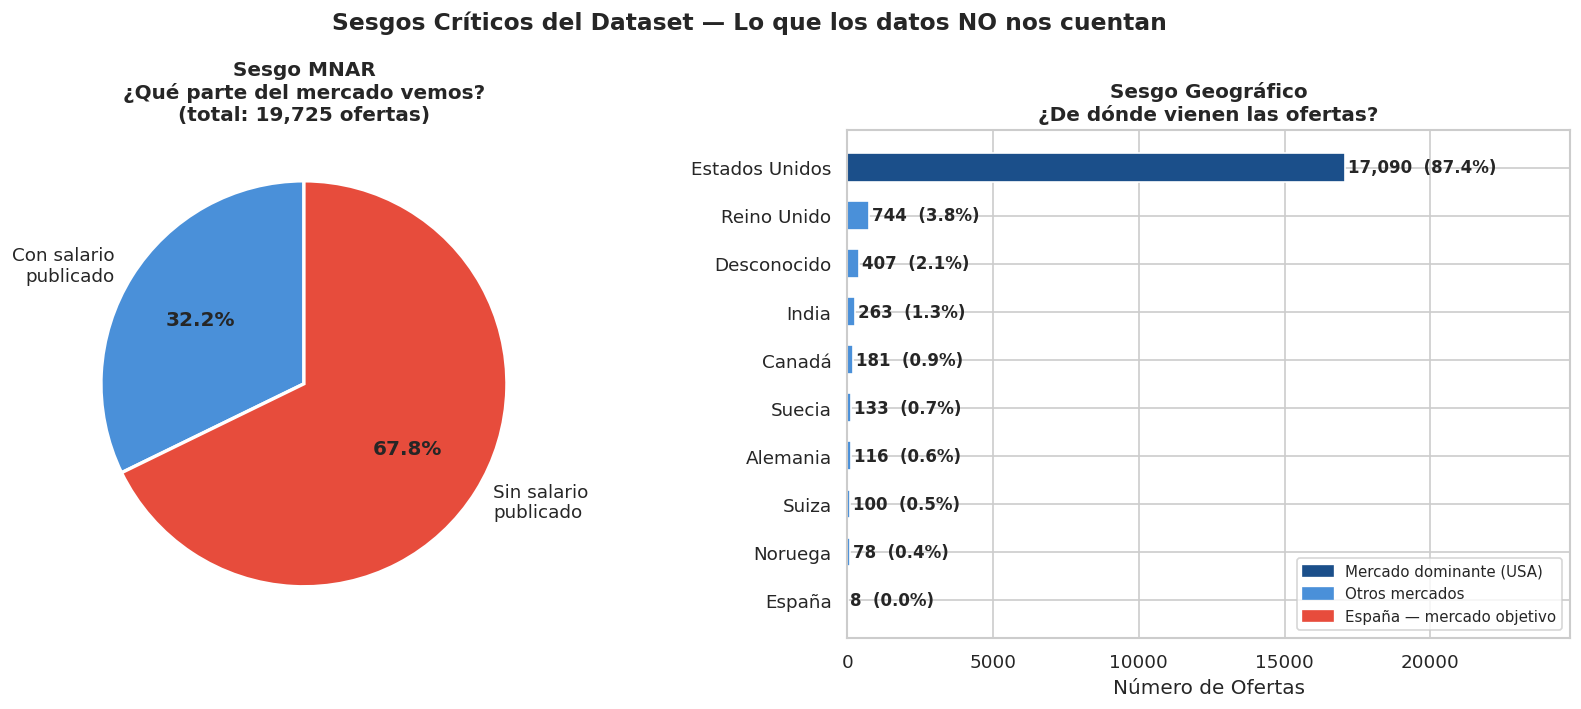

In [ ]:
# Viz — Double Bias: MNAR + Geographical
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left chart: MNAR Bias (pie chart) ─────────────────────
ax1 = axes[0]
total       = len(df)
con_salario = df['salary_annual'].notna().sum()
sin_salario = total - con_salario

wedges, texts, autotexts = ax1.pie(
    [con_salario, sin_salario],
    labels=['Con salario\npublicado', 'Sin salario\npublicado'],
    colors=['#4A90D9', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax1.set_title(f'Sesgo MNAR\n¿Qué parte del mercado vemos?\n'
              f'(total: {total:,} ofertas)',
              fontsize=12, fontweight='bold')

# ── Right chart: Geographical Bias (bars) ────────────────────
ax2 = axes[1]

# Mapping country codes to full names
nombres_paises = {
    'us': 'Estados Unidos', 'gb': 'Reino Unido',
    'in': 'India',          'ca': 'Canadá',
    'se': 'Suecia',         'de': 'Alemania',
    'au': 'Australia',      'fr': 'Francia',
    'es': 'España',         'nl': 'Países Bajos',
    'ch': 'Suiza',          'no': 'Noruega',
    'it': 'Italia',         'mx': 'México',
    'br': 'Brasil',         '0':  'Desconocido'
}

country_counts = df['comp_country'].value_counts().head(9)

# Force Spain even if not in top N
if 'es' in df['comp_country'].values:
    country_counts['es'] = df['comp_country'].value_counts().get('es', 0)

country_counts = country_counts.sort_values(ascending=True)
country_counts.index = [nombres_paises.get(str(i).lower(), str(i))
                        for i in country_counts.index]
total_geo = df['comp_country'].notna().sum()

# Distinct visible colors per country — Spain in red to highlight
colores_barras = []
for pais in country_counts.index:
    if pais == 'España':
        colores_barras.append('#e74c3c')      # red — target market
    elif pais == 'Estados Unidos':
        colores_barras.append('#1B4F8A')      # dark blue — dominates
    else:
        colores_barras.append('#4A90D9')      # medium blue — rest

bars2 = ax2.barh(country_counts.index,
                 country_counts.values,
                 color=colores_barras,
                 edgecolor='white', height=0.6)

for bar, val in zip(bars2, country_counts.values):
    pct = val / total_geo * 100
    ax2.text(bar.get_width() + total_geo * 0.005,
             bar.get_y() + bar.get_height()/2,
             f'{val:,}  ({pct:.1f}%)',
             va='center', fontsize=10, fontweight='bold')

ax2.set_xlim(0, country_counts.max() * 1.45)
ax2.set_title('Sesgo Geográfico\n¿De dónde vienen las ofertas?',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Ofertas')

# Color legend
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1B4F8A', label='Mercado dominante (USA)'),
    Patch(color='#4A90D9', label='Otros mercados'),
    Patch(color='#e74c3c', label='España — mercado objetivo')
]
ax2.legend(handles=leyenda, loc='lower right', fontsize=9)

plt.suptitle('Sesgos Críticos del Dataset — Lo que los datos NO nos cuentan',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_and_show('viz_intro_sesgo.png')

## Interpretación

**Gráfico izquierdo — Sesgo MNAR:**
Solo el 29% de las ofertas publica salario voluntariamente. No es
aleatório — las empresas que publican salario tienden a ser más
grandes y pagar mejor. Todo el análisis salarial de este EDA
se basa en ese 29%.

**Gráfico derecho — Sesgo Geográfico:**
De las ofertas con país identificado, la gran mayoría provienen
de USA. España está subrepresentada o directamente ausente,
lo que significa que las cifras salariales y la demanda de
skills reflejan el mercado estadounidense, no el español.

**Conclusión combinada para DataTalent:**

> *Estamos analizando el 29% del mercado, y ese 29% es
> mayoritariamente USA. Las tendencias son válidas como
> referencia global, pero cualquier decisión comercial
> para el mercado español debe contrastarse con fuentes locales.*



---
## Visualización 1 — Distribución del Salario Anual
**Tipo:** Histograma + KDE + Curva Normal teórica
**Propósito:** Verificar si los salarios en roles de datos siguen una distribución aproximadamente normal y mostrar la asimetría de la distribución real.

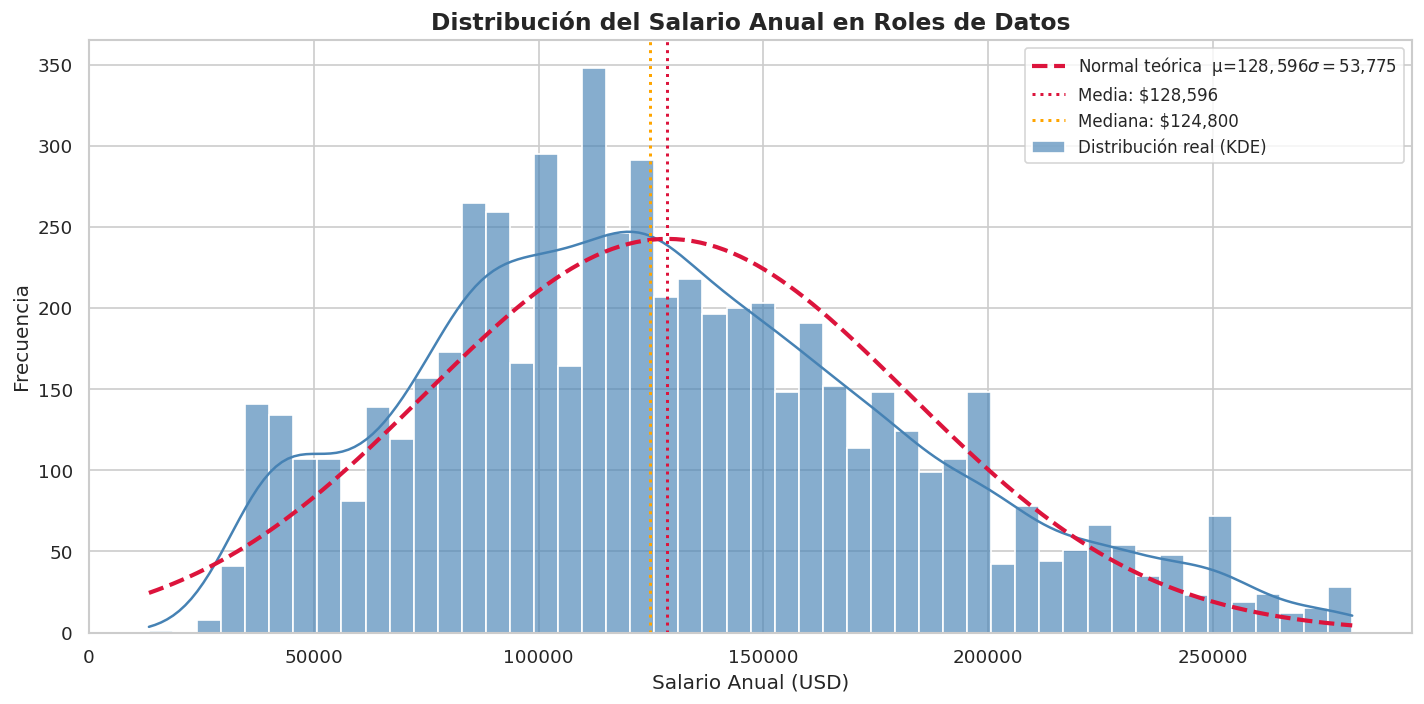

Guardado: viz1_distribucion_salario.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

data_sal = df_sal['salary_annual'].dropna()

# Histogram with real KDE
sns.histplot(data_sal, bins=50, kde=True, color='steelblue',
             alpha=0.65, label='Distribución real (KDE)', ax=ax)

# Theoretical Normal curve overlay
mu, sigma  = data_sal.mean(), data_sal.std()
x          = np.linspace(data_sal.min(), data_sal.max(), 300)
bin_width  = (data_sal.max() - data_sal.min()) / 50
y_normal   = stats.norm.pdf(x, mu, sigma) * len(data_sal) * bin_width

ax.plot(x, y_normal, color='crimson', linewidth=2.5, linestyle='--',
        label=f'Normal teórica  \u03bc=${mu:,.0f}  \u03c3=${sigma:,.0f}')

# Reference lines
ax.axvline(mu,                color='crimson', linestyle=':', linewidth=1.8,
           label=f'Media: ${mu:,.0f}')
ax.axvline(data_sal.median(), color='orange',  linestyle=':', linewidth=1.8,
           label=f'Mediana: ${data_sal.median():,.0f}')

ax.set_title('Distribución del Salario Anual en Roles de Datos', fontsize=14, fontweight='bold')
ax.set_xlabel('Salario Anual (USD)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
save_and_show('viz1_distribucion_salario.png')
print("Guardado: viz1_distribucion_salario.png")

## Interpretación

La distribución real presenta asimetría positiva (cola derecha): la mayoría de los roles
se concentran entre $80k–$150k, pero un segmento reducido de posiciones directivas
en grandes tecnológicas eleva la media hasta $128,596;
por encima de la mediana
$124,800. La curva normal teórica sobreestima la frecuencia de salarios extremos —
confirmando que la distribución real no es normal.

En simples palabras**: Unos pocos salarios muy altos tiran de la media hacia arriba, haciendo que parezca que el mercado paga más de lo que realmente paga la mayoría.

**Implicación para DataTalent:** usar la media como referencia salarial en la propuesta
comercial inflaría las expectativas de los candidatos. La mediana es mejor indicador.

**Limitación crítica:** el 71% de las ofertas no publica salario. Estos datos
representan solo el 29% del mercado, sesgado hacia empresas grandes que pagan mejor.
El salario real del mercado probablemente es más bajo.

---
## Visualización 2 — Salario por Nivel de Experiencia (Boxplot)
**Tipo:** Diagrama de caja (boxplot)
**Propósito:** Comparar la distribución salarial entre niveles de experiencia y detectar outliers por nivel.

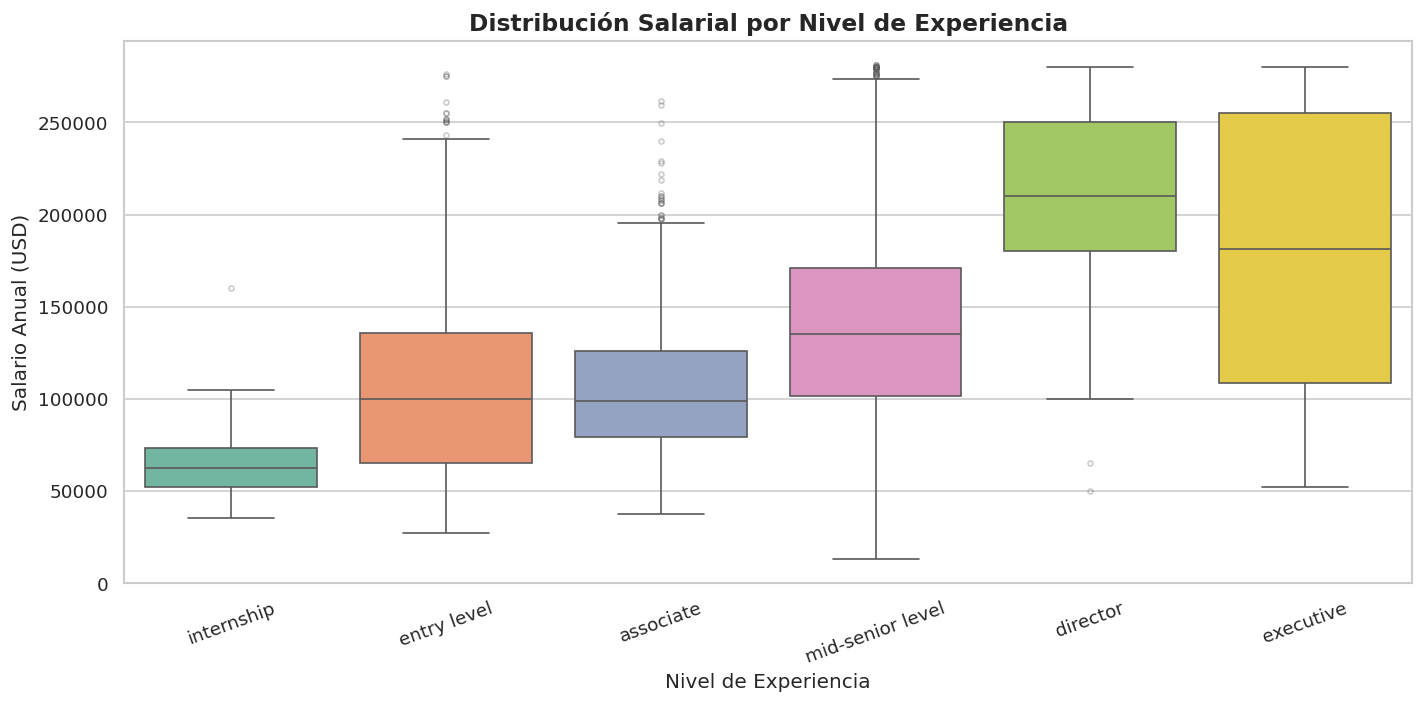

Guardado: viz2_boxplot_experiencia.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

orden = ['internship','entry level','associate','mid-senior level','director','executive']
df_box = df_sal[df_sal['formatted_experience_level'].isin(orden)].copy()
orden_present = [o for o in orden if o in df_box['formatted_experience_level'].unique()]

sns.boxplot(
    data=df_box,
    x='formatted_experience_level',
    y='salary_annual',
    order=orden_present,
    palette='Set2',
    flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.3},
    ax=ax
)

ax.set_title('Distribución Salarial por Nivel de Experiencia', fontsize=14, fontweight='bold')
ax.set_xlabel('Nivel de Experiencia', fontsize=12)
ax.set_ylabel('Salario Anual (USD)', fontsize=12)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
save_and_show('viz2_boxplot_experiencia.png')
print("Guardado: viz2_boxplot_experiencia.png")

## Interpretación

La escalera salarial es estadísticamente clara: Director y Executive tienen medianas
~2x superiores a Entry Level. Sin embargo, dos hallazgos merecen atención:

1. La caja de Executive es la más amplia: dos directivos pueden cobrar
   cantidades radicalmente distintas según industria y empresa.
2. Internship tiene outliers en $160k — probablemente prácticas remuneradas en FAANG,
   no representativas del mercado general.

**Implicación:** el reskilling de Entry a Mid-Senior es el salto con mayor ROI ajustado
al riesgo. El salto a Director implica mayor variabilidad: el resultado depende más del
contexto que de las habilidades.

## Visualización 3 — Comparativa de Skills: Mercado Global vs España
**Tipo:** Gráfico de barras horizontales doble
**Propósito:** Contrastar las habilidades más demandadas a nivel global con
las del mercado español, identificando si el programa de reskilling de
DataTalent requiere adaptación curricular para el mercado local.

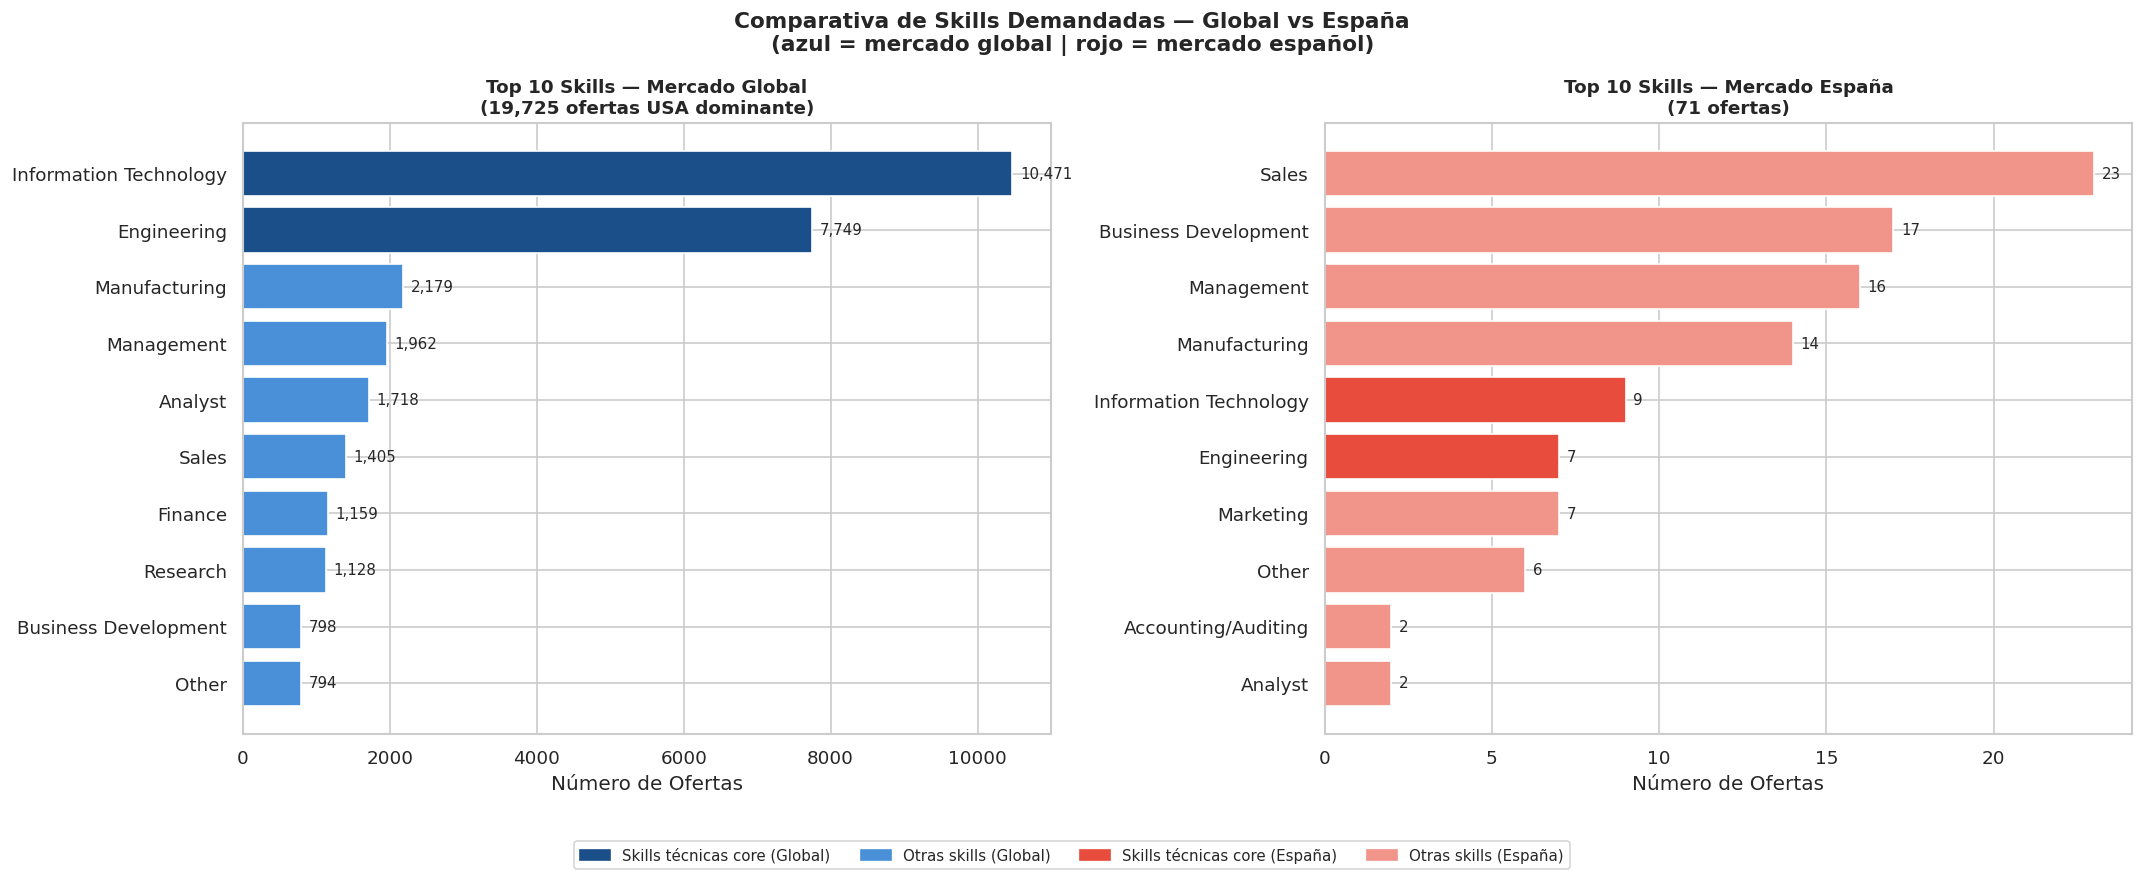

In [ ]:
# Viz 3 — Skills Comparison: Global vs Spain
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left panel: Global skills ─────────────────────
ax1 = axes[0]

if 'job_skills_list' in df.columns:
    df_sk = df[['job_id','job_skills_list']].dropna(subset=['job_skills_list']).copy()
    df_sk['skill'] = df_sk['job_skills_list'].str.split(', ')
    df_sk_e = df_sk.explode('skill')
    sk_global = df_sk_e['skill'].value_counts().head(10)

    colores_global = ['#1B4F8A' if s in ['Information Technology','Engineering']
                      else '#4A90D9' for s in sk_global.index[::-1]]

    bars1 = ax1.barh(sk_global.index[::-1], sk_global.values[::-1],
                     color=colores_global, edgecolor='white')

    for bar, val in zip(bars1, sk_global.values[::-1]):
        ax1.text(bar.get_width() + sk_global.max() * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

ax1.set_title('Top 10 Skills — Mercado Global\n(19,725 ofertas USA dominante)',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Número de Ofertas')

# ── Right panel: Spain skills ──────────────────────────────────
ax2 = axes[1]

dm = pd.read_csv('/content/drive/MyDrive/archive/data_maestro_completo.csv',
                 low_memory=False)
es = dm[dm['comp_country'] == 'ES'].copy()

if 'job_skills_list' in es.columns:
    es_sk = es[['job_id','job_skills_list']].dropna(subset=['job_skills_list']).copy()
    es_sk['skill'] = es_sk['job_skills_list'].str.split(', ')
    es_sk_e = es_sk.explode('skill')
    sk_spain = es_sk_e['skill'].str.strip().value_counts().head(10)

    colores_spain = ['#e74c3c' if s in ['Information Technology','Engineering']
                     else '#f1948a' for s in sk_spain.index[::-1]]

    bars2 = ax2.barh(sk_spain.index[::-1], sk_spain.values[::-1],
                     color=colores_spain, edgecolor='white')

    for bar, val in zip(bars2, sk_spain.values[::-1]):
        ax2.text(bar.get_width() + sk_spain.max() * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

ax2.set_title(f'Top 10 Skills — Mercado España\n({len(es)} ofertas)',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Número de Ofertas')

# ── Legend ───────────────────────────────────────────────────────
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#1B4F8A', label='Skills técnicas core (Global)'),
    Patch(color='#4A90D9', label='Otras skills (Global)'),
    Patch(color='#e74c3c', label='Skills técnicas core (España)'),
    Patch(color='#f1948a', label='Otras skills (España)'),
]
fig.legend(handles=leyenda, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Comparativa de Skills Demandadas — Global vs España\n'
             '(azul = mercado global | rojo = mercado español)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
save_and_show('viz3_skills_global_vs_spain.png')

## Interpretación

El gráfico revela una diferencia estructural entre ambos mercados:

**Mercado Global (azul):**
Information Technology y Engineering dominan con enorme ventaja —
el mercado global busca ante todo perfiles técnicos puros.
Management, Finance y Sales aparecen como skills complementarias
pero claramente secundarias.

**Mercado España (rojo):**
El perfil se invierte. Sales, Business Development y Management
lideran — España busca perfiles comerciales y de gestión que
además entiendan los datos. Information Technology y Engineering
aparecen pero en quinta y sexta posición, con números muy bajos.
Marketing aparece en España y no en el top global.

**Lo que esto significa para DataTalent:**

> El candidato ideal para el mercado español no es un técnico puro
> que aprende a comunicarse — es un perfil comercial o de gestión
> que aprende Python y SQL para potenciar lo que ya sabe hacer.

Esto justifica un **programa de reskilling específico para España**
diferente al currícculo global, con mayor peso en:
- Análisis de datos aplicado a ventas y negocio
- Visualización orientada a decisiones comerciales
- Python y SQL como herramientas, no como fin en sí mismas

> ⚠️ **Limitación:** España tiene solo 71 ofertas totales (8 de roles
> de datos específicamente) frente a 19,725 globales. Las tendencias
> españolas son orientativas — contrastar con Infojobs o Tecnoempleo
> antes de tomar decisiones curriculares definitivas.


---
## Visualización 4 — Top 10 Industrias con más Ofertas (Barras verticales)
**Tipo:** Gráfico de barras verticales
**Propósito:** Identificar qué sectores concentran la mayor demanda de roles de datos.

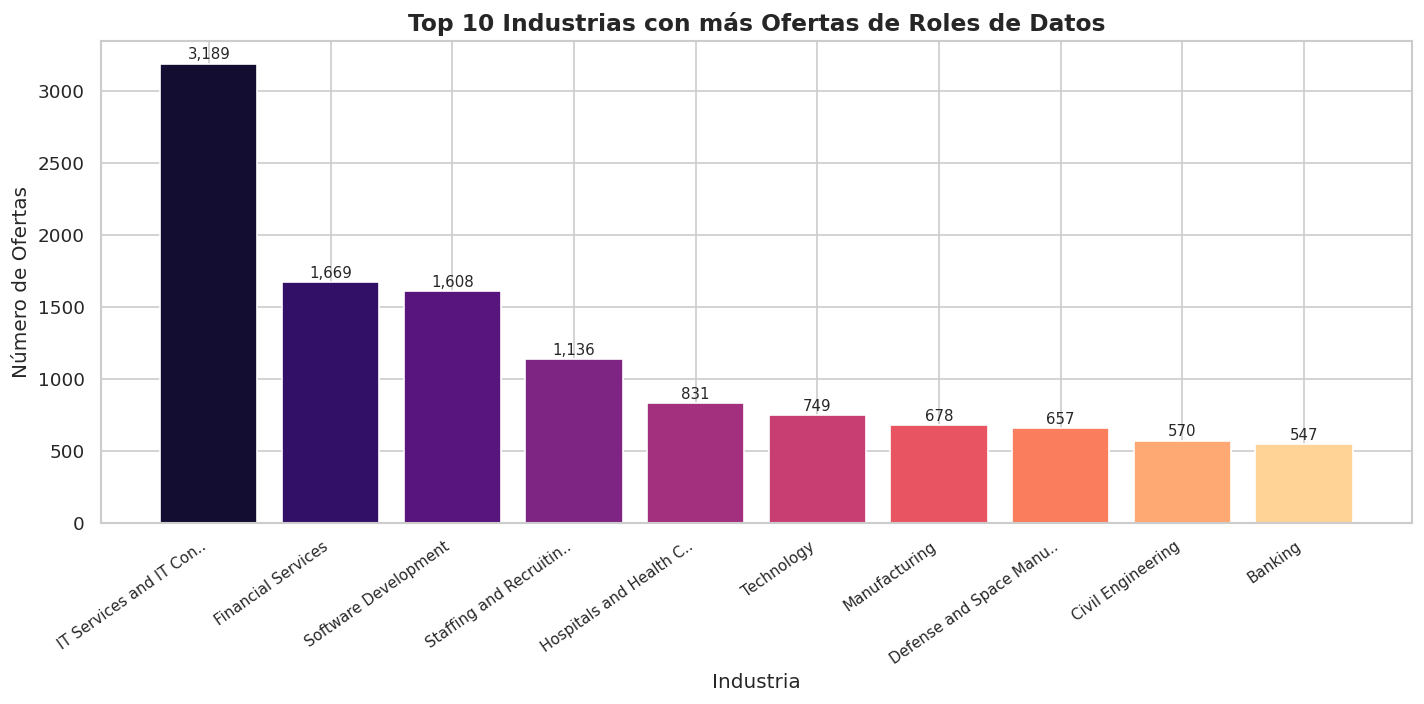

Guardado: viz4_top_industrias.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

if 'job_industries_list' in df.columns:
    df_ind    = df[['job_id','job_industries_list']].dropna(subset=['job_industries_list']).copy()
    df_ind['industry'] = df_ind['job_industries_list'].str.split(', ')
    df_ind_e  = df_ind.explode('industry')
    ind_cnt   = df_ind_e['industry'].value_counts().head(10)

    colors = sns.color_palette('magma', len(ind_cnt))
    bars   = ax.bar(range(len(ind_cnt)), ind_cnt.values, color=colors, edgecolor='white')

    ax.set_xticks(range(len(ind_cnt)))
    ax.set_xticklabels(
        [t[:22] + '..' if len(t) > 22 else t for t in ind_cnt.index],
        rotation=35, ha='right', fontsize=9
    )
    for bar, val in zip(bars, ind_cnt.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ind_cnt.max() * 0.01,
                f'{val:,}', ha='center', fontsize=9)
else:
    ax.text(0.5, 0.5, 'Columna job_industries_list no disponible',
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_title('Top 10 Industrias con más Ofertas de Roles de Datos', fontsize=14, fontweight='bold')
ax.set_xlabel('Industria', fontsize=12)
ax.set_ylabel('Número de Ofertas', fontsize=12)
plt.tight_layout()
save_and_show('viz4_top_industrias.png')
print("Guardado: viz4_top_industrias.png")

## Interpretación

IT Services concentra el doble de ofertas que el segundo sector (Financial Services), confirmando su papel como principal empleador de perfiles de datos.
El dato más relevante para DataTalent no es el top 1, sino los sectores del 4 al 10: Staffing,
Healthcare, Manufacturing y Defense presentan demanda significativa con menor
competencia entre vuestros alumnos.

**Recomendación HRIA:**  orientar todos los candidatos hacia IT Services maximiza la **cantidad
de ofertas** pero maximiza también la competencia. Realizar una estrategia de nicho hacia
Healthcare o Manufacturing puede mejorar la tasa de colocación al orientarlos.

**Sesgo geográfico:** esta distribución refleja el mercado USA. En España, Banca,
Turismo y Sector Público tendrían mayor peso relativo.


## Visualización 5 — Vistas vs Solicitudes por Oferta (Scatter + tendencia)
**Tipo:** Diagrama de dispersión con regresión lineal
**Propósito:** Explorar la correlación entre la visibilidad de una oferta y las candidaturas que genera.

**Interpretación:** La correlación positiva entre vistas y solicitudes es esperada: una oferta más visible atrae más candidaturas. Sin embargo, la dispersión revela que la visibilidad no lo explica todo: la calidad de la descripción, el salario publicado y la reputación de la empresa también influyen en la tasa de conversión vista→solicitud. Ofertas con muchas vistas y pocas solicitudes pueden tener descripciones poco atractivas o requisitos excesivos. **Para DataTalent:** asesorar a empresas clientes sobre optimización de descripciones puede mejorar su pool de candidatos.

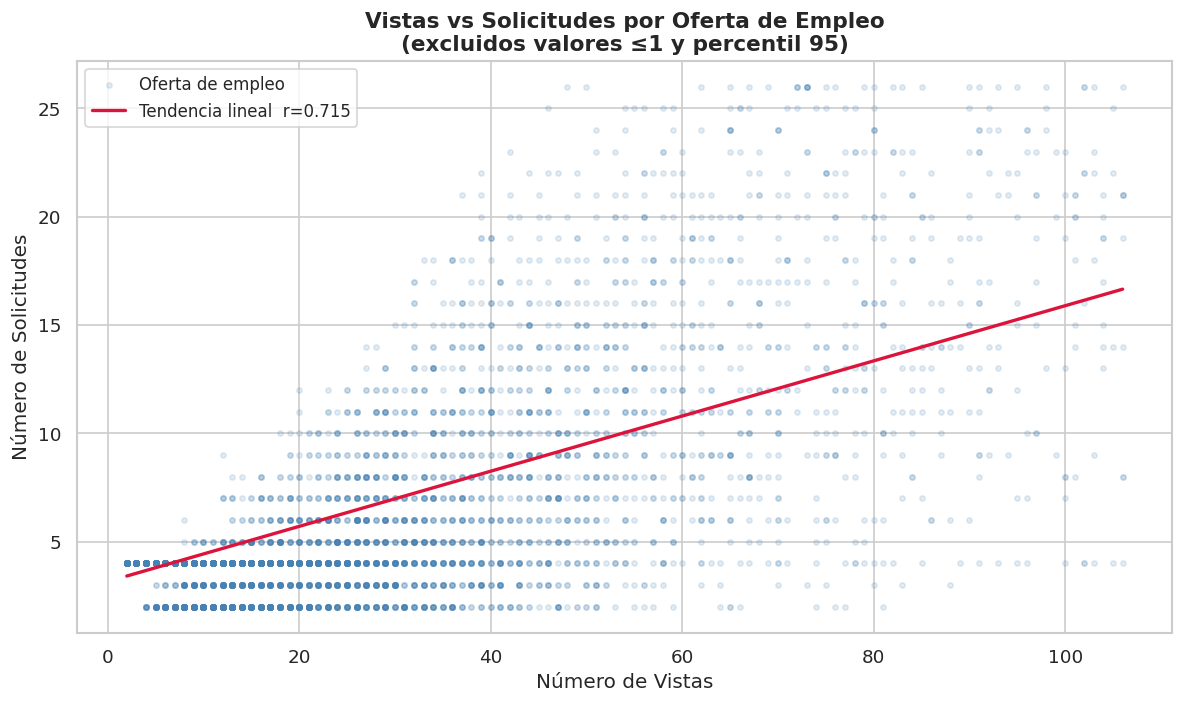

Correlación Pearson r = 0.715  (p-valor = 0.00e+00)


In [ ]:
# Viz5 — Scatter Views vs Applications
fig, ax = plt.subplots(figsize=(10, 6))

df_sc = df[['views','applies']].dropna()
df_sc = df_sc[(df_sc['views'] > 1) & (df_sc['applies'] > 1)]
p95_v = df_sc['views'].quantile(0.95)
p95_a = df_sc['applies'].quantile(0.95)
df_sc = df_sc[(df_sc['views'] <= p95_v) & (df_sc['applies'] <= p95_a)]

ax.scatter(df_sc['views'], df_sc['applies'],
           alpha=0.15, s=10, color='steelblue', label='Oferta de empleo')

m, b, r, p_val, _ = stats.linregress(df_sc['views'], df_sc['applies'])
x_line = np.linspace(df_sc['views'].min(), df_sc['views'].max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2,
        label=f'Tendencia lineal  r={r:.3f}')

ax.set_title('Vistas vs Solicitudes por Oferta de Empleo\n'
             '(excluidos valores ≤1 y percentil 95)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Número de Vistas', fontsize=12)
ax.set_ylabel('Número de Solicitudes', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
save_and_show('viz5_scatter_vistas_solicitudes.png')

print(f"Correlación Pearson r = {r:.3f}  (p-valor = {p_val:.2e})")

## Interpretación

La correlación r=0.715 indica una **relación positiva moderada-alta** entre
vistas y solicitudes — las ofertas más vistas reciben más candidaturas,
lo cual es esperable pero no automático.

Sin embargo, el gráfico revela algo más importante: **la gran mayoría de
ofertas se concentran en la franja de 2–5 solicitudes independientemente
de las vistas** (puntos apilados en la parte inferior). Esto significa que
tener más visibilidad no garantiza más candidatos de calidad.

**Dos perfiles de oferta claros:**

- **Ofertas de baja visibilidad (< 20 vistas):** concentran la mayoría
  de los datos — mercado real donde compite la mayoría de candidatos.
- **Ofertas de alta visibilidad (> 60 vistas):** pocas pero con más
  solicitudes — generalmente grandes empresas con marca empleadora fuerte.

**Implicación para DataTalent:** un candidato bien preparado tiene más
probabilidades de destacar en ofertas de baja visibilidad, donde la
competencia es menor, que en ofertas virales donde compite con cientos
de perfiles. La estrategia de búsqueda de empleo importa tanto como
las habilidades técnicas.

---
## Visualización 6 — Heatmap de Correlaciones
**Tipo:** Mapa de calor (heatmap)
**Propósito:** Visualizar simultáneamente todas las correlaciones entre variables numéricas.

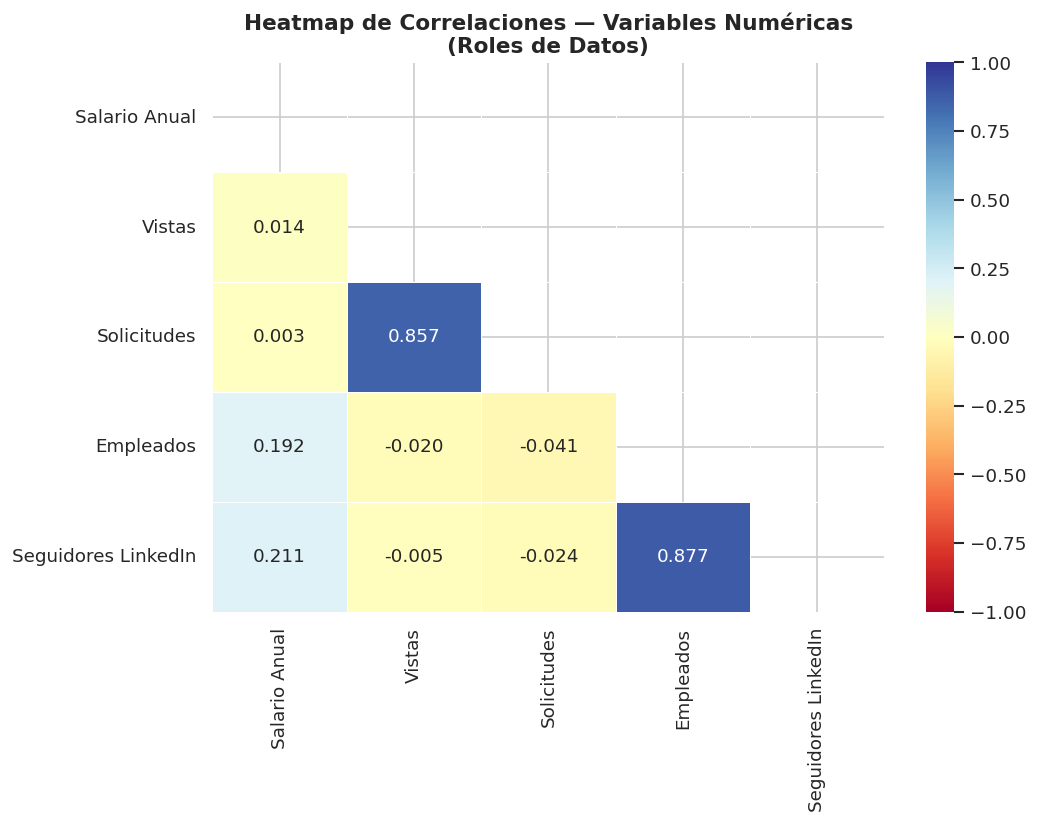

Guardado: viz6_heatmap_correlaciones.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

num_cols = [c for c in ['salary_annual','views','applies','employee_count','follower_count']
            if c in df_sal.columns]
corr_mat = df_sal[num_cols].corr()
mask     = np.triu(np.ones_like(corr_mat, dtype=bool))

# More readable labels
labels = {
    'salary_annual': 'Salario Anual',
    'views':         'Vistas',
    'applies':       'Solicitudes',
    'employee_count':'Empleados',
    'follower_count':'Seguidores LinkedIn',
}
corr_renamed = corr_mat.rename(index=labels, columns=labels)
mask_renamed = np.triu(np.ones_like(corr_renamed, dtype=bool))

sns.heatmap(
    corr_renamed,
    mask=mask_renamed,
    annot=True,
    fmt='.3f',
    cmap='RdYlBu',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 11}
)

ax.set_title('Heatmap de Correlaciones — Variables Numéricas\n(Roles de Datos)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_and_show('viz6_heatmap_correlaciones.png')
print("Guardado: viz6_heatmap_correlaciones.png")

## Interpretación
El heatmap muestra de un vistazo las relaciones lineales entre todas las variables numéricas. Los colores azules indican correlación positiva, los rojos negativa, y el amarillo ausencia de relación lineal.
Dos correlaciones dominan el heatmap:

- **Empleados ↔ Seguidores LinkedIn (0.877):** las empresas grandes tienen más
  seguidores — relación de tamaño, no de relevancia para el análisis salarial.
- **Vistas ↔ Solicitudes (0.857):** más visibilidad genera más candidaturas,
  pero con alta variabilidad individual (ver Viz 5).

Lo más relevante es lo que NO aparece: el salario tiene correlación casi nula con
vistas (0.014) y solicitudes (0.003). Publicar el salario no atrae significativamente
más candidatos — lo que contradice la intuición habitual.

**Limitación:** Pearson solo detecta relaciones lineales. Relaciones en U o
logarítmicas no quedarían reflejadas aquí.

## Visualización 7 — Distribución de Ofertas por Tipo de Contrato

Esta visualización muestra cuántas ofertas de roles de datos existen
por cada modalidad contractual, permitiendo identificar qué tipo de
contrato domina el mercado.

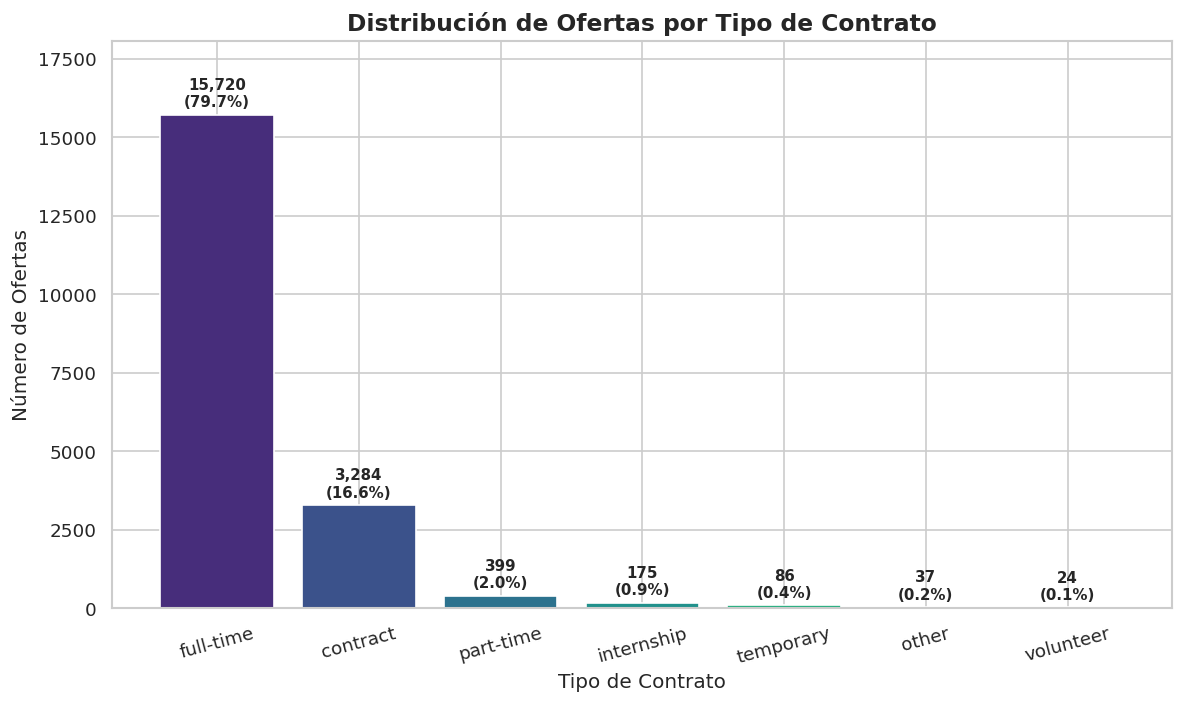

In [ ]:
# Viz7 — Job Postings Distribution by Contract Type
fig, ax = plt.subplots(figsize=(10, 6))

conteo = df['formatted_work_type'].value_counts()
total  = conteo.sum()
colores = sns.color_palette('viridis', len(conteo))

bars = ax.bar(conteo.index, conteo.values, color=colores, edgecolor='white')

# Labels above each bar
for bar, (tipo, cnt) in zip(bars, conteo.items()):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{cnt:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Distribución de Ofertas por Tipo de Contrato',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tipo de Contrato')
ax.set_ylabel('Número de Ofertas')
ax.set_ylim(0, conteo.max() * 1.15)
plt.xticks(rotation=15)
plt.tight_layout()
save_and_show('viz7_tipo_contrato.png')

## Interpretación

Full-time representa casi el 80% del mercado de roles de datos, confirmando
que el sector busca talento estable a largo plazo, no puntual.

El 16.6% de contratos refleja un mercado de consultoría y freelance activo —
una salida real para candidatos que no encuentren posición fija de inmediato.

Las modalidades minoritarias (part-time, internship, volunteer) tienen presencia
residual y no representan rutas viables de entrada al sector de forma estable.

**Implicación para DataTalent:** el programa de reskilling debe preparar
candidatos principalmente para posiciones full-time, pero incluir módulos
de posicionamiento freelance como salida alternativa para perfiles con
experiencia previa en otras áreas.

> ⚠️ **Sesgo geográfico:** esta distribución refleja el mercado USA.
> En España el peso del contrato indefinido vs temporal puede diferir
> significativamente debido al marco laboral europeo.

---
## Visualización 8 — Salario Medio por Nivel de Experiencia con Intervalo de Confianza
**Tipo:** Gráfico de barras con barras de error (IC 95%)
**Propósito:** Cuantificar y visualizar la escalera salarial con su incertidumbre estadística.

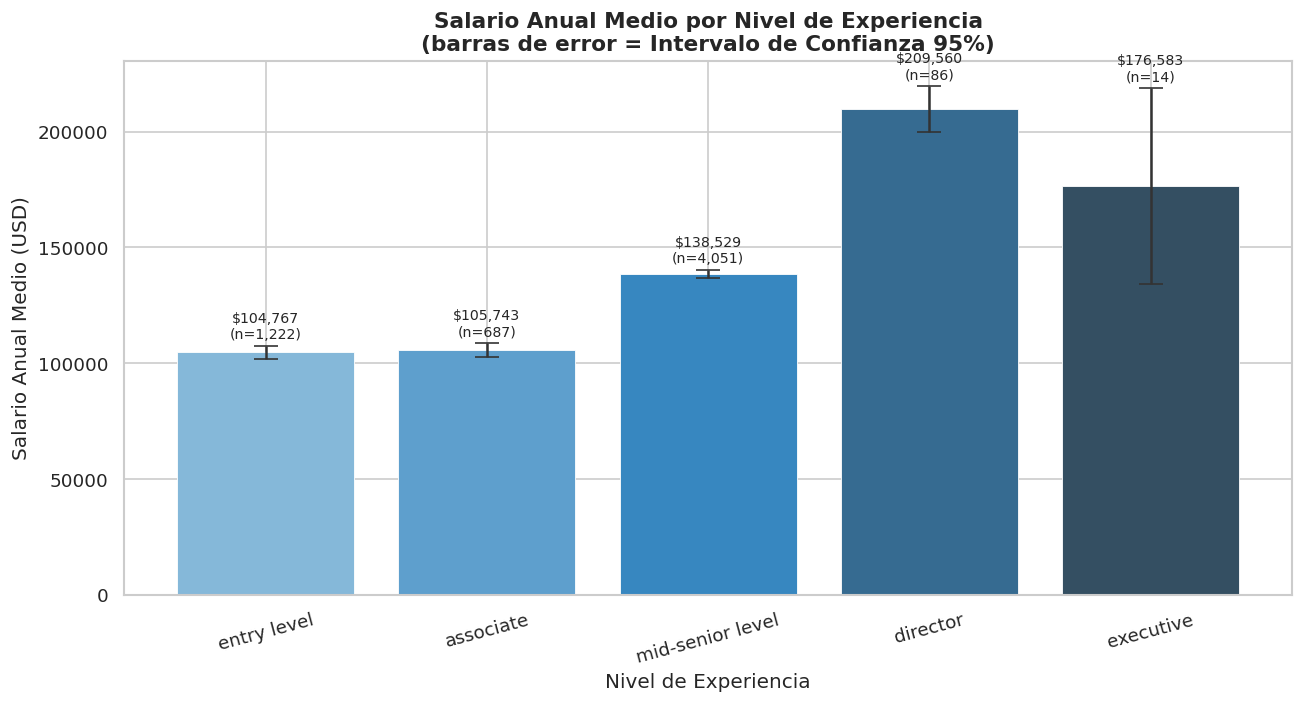

Guardado: viz8_salario_por_experiencia.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

orden = ['entry level','associate','mid-senior level','director','executive']
df_e  = df_sal[df_sal['formatted_experience_level'].isin(orden)].copy()

exp_stats = (df_e.groupby('formatted_experience_level')['salary_annual']
             .agg(['mean','std','count'])
             .reindex([o for o in orden if o in df_e['formatted_experience_level'].unique()]))

means  = exp_stats['mean'].values
stds   = exp_stats['std'].fillna(0).values
counts = exp_stats['count'].values
labels = exp_stats.index.tolist()
ses    = np.where(counts > 0, stds / np.sqrt(counts), 0)

palette = sns.color_palette('Blues_d', len(labels))
bars    = ax.bar(labels, means, yerr=ses * 1.96, capsize=7,
                 color=palette, edgecolor='white', linewidth=0.5,
                 error_kw={'elinewidth': 1.5, 'ecolor': '#333333'})

for i, (bar, mean, n) in enumerate(zip(bars, means, counts)):
    ax.text(bar.get_x() + bar.get_width() / 2,
            mean + ses[i] * 1.96 + max(means) * 0.015,
            f'${mean:,.0f}\n(n={n:,})', ha='center', fontsize=8.5)

ax.set_title('Salario Anual Medio por Nivel de Experiencia\n(barras de error = Intervalo de Confianza 95%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de Experiencia', fontsize=12)
ax.set_ylabel('Salario Anual Medio (USD)', fontsize=12)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
save_and_show('viz8_salario_por_experiencia.png')
print("Guardado: viz8_salario_por_experiencia.png")

## Interpretación

**Lectura por nivel:**

- **Entry Level y Associate** tienen medias muy similares (~$100k) con intervalos
  que casi se solapan — la diferencia salarial entre ambos es pequeña y poco
  significativa. Son niveles prácticamente equivalentes en términos de retribución.

- **Mid-Senior** marca el primer salto claro — intervalo separado de Entry Level,
  confirma que el reskilling hacia este nivel tiene un retorno real y cuantificable.

- **Director y Executive** muestran los IC más amplios — alta variabilidad y
  muestras más pequeñas (n bajo). Las estimaciones para estos niveles deben
  tomarse con cautela: dos directivos en empresas distintas pueden cobrar
  cantidades radicalmente diferentes.

**Argumento cuantificado para DataTalent:**

Si la diferencia Entry→Mid-Senior es ~$40k/año y el programa cuesta €6,000,
el ROI se recupera en menos de 2 meses de trabajo. Este es el único número
que necesita el slide de propuesta comercial.

> ⚠️ **Sesgo MNAR:** medias calculadas sobre el 29% de ofertas con salario
> publicado, sesgado hacia empresas grandes. Los valores absolutos son
> orientativos — la tendencia (escalera salarial) sí es fiable.

## Visualización 9 — Salario Mediano por Rol de Datos

Esta visualización compara directamente los tres roles principales de datos
según su salario mediano, incluyendo el IQR como medida de variabilidad.
Responde a la pregunta clave: ¿hacia qué rol merece la pena orientar a un
candidato en reskilling para maximizar su salario?

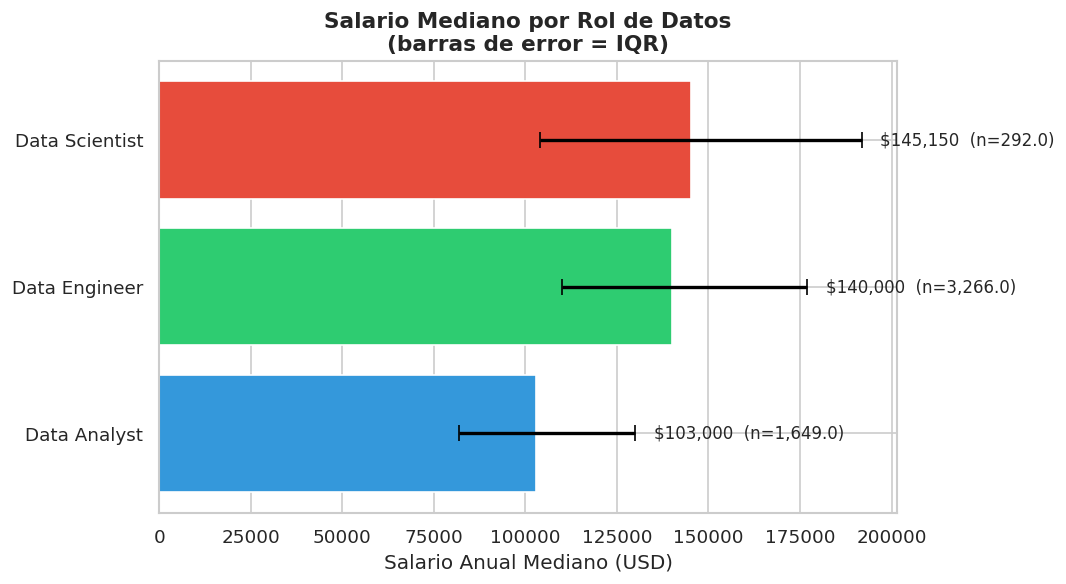

In [ ]:
# Viz9 — Median salary by role (Data Analyst vs Engineer vs Scientist)
fig, ax = plt.subplots(figsize=(9, 5))

df_p2 = df_sal.copy()
df_p2['rol'] = 'Otro'
df_p2.loc[df_p2['title'].str.contains('analyst', case=False, na=False), 'rol'] = 'Data Analyst'
df_p2.loc[df_p2['title'].str.contains('engineer', case=False, na=False), 'rol'] = 'Data Engineer'
df_p2.loc[df_p2['title'].str.contains('scientist|science', case=False, na=False), 'rol'] = 'Data Scientist'

rol_sal = (df_p2[df_p2['rol'] != 'Otro']
           .groupby('rol')['salary_annual']
           .agg(Mediana='median', Q1=lambda x: x.quantile(0.25),
                Q3=lambda x: x.quantile(0.75), N='count')
           .sort_values('Mediana', ascending=True))

colores = ['#3498db', '#2ecc71', '#e74c3c']
bars = ax.barh(rol_sal.index, rol_sal['Mediana'], color=colores, edgecolor='white')

# IQR error bars
for i, (rol, row) in enumerate(rol_sal.iterrows()):
    ax.errorbar(row['Mediana'], i,
                xerr=[[row['Mediana']-row['Q1']], [row['Q3']-row['Mediana']]],
                fmt='none', color='black', capsize=5, linewidth=2)
    ax.text(row['Q3'] + 5000, i,
        f"${row['Mediana']:,.0f}  (n={row['N']:,})",
        va='center', fontsize=10)

ax.set_title('Salario Mediano por Rol de Datos\n(barras de error = IQR)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Salario Anual Mediano (USD)')
plt.tight_layout()
save_and_show('viz9_salario_por_rol.png')

## Interpretación

El gráfico revela una tensión clara entre accesibilidad y salario:

- **Data Analyst** es la puerta de entrada óptima — mayor proporción de
  ofertas entry level del mercado y salario mediano competitivo. Es la
  primera colocación con mayor probabilidad de éxito para un candidato
  recién requalificado.

- **Data Engineer** invierte la relación — menos hueco para juniors pero
  salario más alto. Es el objetivo natural tras 2–3 años de experiencia
  como Analyst.

- **Data Scientist** combina el menor acceso para juniors con la mayor
  variabilidad salarial — el rol más exigente y con resultado más incierto.
  No es una primera posición realista para la mayoría de candidatos.

**Conclusión accionable para DataTalent:** la ruta de reskilling óptima
no es apuntar directamente al rol con mayor salario, sino maximizar la
probabilidad de primera colocación y crecer desde ahí.

> ⚠️ **Sesgo MNAR:** salarios basados en el 29% de ofertas con datos
> publicados, sesgados hacia empresas grandes. Los valores reales del
> mercado probablemente son inferiores.

## Visualización 10 — Accesibilidad para Juniors vs Salario Mediano por Rol

Esta visualización cruza los dos factores de decisión más importantes para
DataTalent: cuánto hueco tiene cada rol para perfiles junior (barras verdes)
y cuánto paga ese rol en el mercado (barras azules). Permite responder de
forma visual y directa la pregunta estratégica del programa de reskilling.

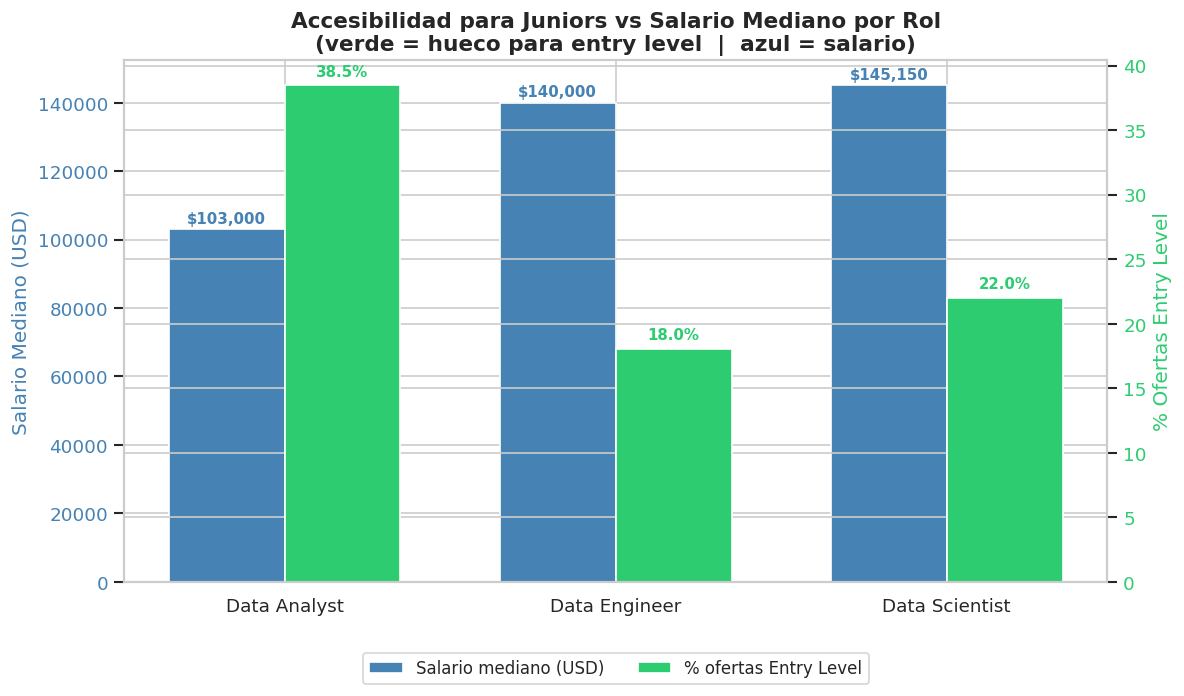

In [ ]:
# Viz 10 — Junior Accessibility vs Median Salary by Role
# Calculate probs_entry needed for this visualization
df_p = df.copy()
df_p['is_entry'] = df_p['formatted_experience_level'].str.contains(
    'entry|internship|associate', case=False, na=False)
df_p['is_ds'] = df_p['title'].str.contains('scientist|science', case=False, na=False)
df_p['is_de'] = df_p['title'].str.contains('data engineer', case=False, na=False)
df_p['is_da'] = df_p['title'].str.contains('data analyst', case=False, na=False)

p_e_ds = df_p.loc[df_p['is_ds'], 'is_entry'].mean()
p_e_de = df_p.loc[df_p['is_de'], 'is_entry'].mean()
p_e_da = df_p.loc[df_p['is_da'], 'is_entry'].mean()
p_e_all = df_p['is_entry'].mean()

probs_entry = {
    'Data Analyst':   p_e_da,
    'Data Engineer':  p_e_de,
    'Data Scientist': p_e_ds
}

mejor_rol = max(probs_entry, key=probs_entry.get)

fig, ax1 = plt.subplots(figsize=(10, 6))

roles_nombres = ['Data Analyst', 'Data Engineer', 'Data Scientist']
salarios      = [rol_sal.loc[r, 'Mediana'] for r in roles_nombres]
probs         = [probs_entry[r] * 100 for r in roles_nombres]
x             = np.arange(len(roles_nombres))
width         = 0.35

# Salary bars (left axis)
ax1.bar(x - width/2, salarios, width, color='steelblue',
        label='Salario mediano (USD)', edgecolor='white')
ax1.set_ylabel('Salario Mediano (USD)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Probability bars (right axis)
ax2 = ax1.twinx()
ax2.bar(x + width/2, probs, width, color='#2ecc71',
        label='% ofertas Entry Level', edgecolor='white')
ax2.set_ylabel('% Ofertas Entry Level', color='#2ecc71', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2ecc71')

# Labels
for i, (sal, prob) in enumerate(zip(salarios, probs)):
    ax1.text(i - width/2, sal + 1000, f'${sal:,.0f}',
             ha='center', va='bottom', fontsize=9, color='steelblue', fontweight='bold')
    ax2.text(i + width/2, prob + 0.5, f'{prob:.1f}%',
             ha='center', va='bottom', fontsize=9, color='#2ecc71', fontweight='bold')

ax1.set_title('Accesibilidad para Juniors vs Salario Mediano por Rol\n(verde = hueco para entry level  |  azul = salario)',
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(roles_nombres, fontsize=11)

# Combined legend
# Combined legend fuera del gráfico
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.12),  # below the chart
           ncol=2, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)  # space for bottom legend
save_and_show('viz10_accesibilidad_vs_salario.png')

## Interpretación

Los tres roles muestran salarios medianos por encima de $120k, confirmando
que cualquier especialización en datos tiene un retorno económico alto.
Sin embargo, hay diferencias relevantes para la estrategia de DataTalent:

- **Data Scientist** lidera en salario mediano pero tiene el IQR más amplio —
  alta variabilidad, el resultado depende mucho de la empresa y el sector.
- **Data Engineer** combina salario competitivo con mayor volumen de ofertas
  (n más alto) — mayor probabilidad de colocación.
- **Data Analyst** es el punto de entrada más accesible según P(Entry Level)
  y ofrece un salario mediano sólido como primera posición.

**Recomendación para DataTalent:** diseñar el programa en dos velocidades:

1. **Ruta rápida** → Data Analyst como primera colocación (más hueco para juniors,
   salario sólido, menor competencia)
2. **Ruta senior** → Data Engineer o Data Scientist tras 2–3 años de experiencia
   (mayor salario, mayor exigencia)

> ⚠️ **Sesgo MNAR:** basado en el 29% de ofertas con salario publicado,
> sesgado hacia empresas grandes que pagan mejor. Los valores reales
> del mercado probablemente son inferiores.

In [ ]:
# Automatic recommendation
print("\n=== Recomendación para DataTalent ===")
roles = {'Data Scientist': p_e_ds, 'Data Engineer': p_e_de, 'Data Analyst': p_e_da}
mejor_rol = max(roles, key=roles.get)
print(f"Rol más accesible para junior: {mejor_rol} ({roles[mejor_rol]*100:.1f}%)")

# ── How many times more accessible ───────────────────────────────────────
print("\n=== Comparativa — ¿Cuántas veces más accesible? ===")
for rol, prob in roles.items():
    if rol != mejor_rol:
        ratio = roles[mejor_rol] / prob if prob > 0 else float('inf')
        print(f"  {mejor_rol} tiene {ratio:.1f}x más hueco para juniors que {rol}")


=== Recomendación para DataTalent ===
Rol más accesible para junior: Data Analyst (38.5%)

=== Comparativa — ¿Cuántas veces más accesible? ===
  Data Analyst tiene 1.7x más hueco para juniors que Data Scientist
  Data Analyst tiene 2.1x más hueco para juniors que Data Engineer


## Visualización 11 — ROI del Programa de Reskilling

Esta visualización estima el retorno económico que obtendría un candidato
tras completar el programa de reskilling de DataTalent, partiendo del
Salario Mínimo Interprofesional español (SMI 2024: €1,221/mes × 14 pagas).

El objetivo es cuantificar el valor del programa para el candidato y
estimar cuánto estaría dispuesto a pagar por él.

> ⚠️ **Nota metodológica:** los salarios post-reskilling provienen del
> dataset LinkedIn USA (29% de ofertas con salario publicado, sesgo MNAR
> al alza). Se han convertido a EUR (1 USD = 0.92 EUR) como aproximación.
> Los valores reales del mercado español son inferiores — usar como
> referencia de tendencia, no como cifra exacta.

=== ROI del Programa de Reskilling ===
Salario inicial (SMI):  €    17,094/año
Coste del programa:     €     6,000

Rol                   Salario post  Ganancia/año  Recupera en
--------------------------------------------------------------
Data Analyst         €     94,760 €     77,666        0.9 meses
Data Engineer        €    128,800 €    111,706        0.6 meses
Data Scientist       €    133,538 €    116,444        0.6 meses


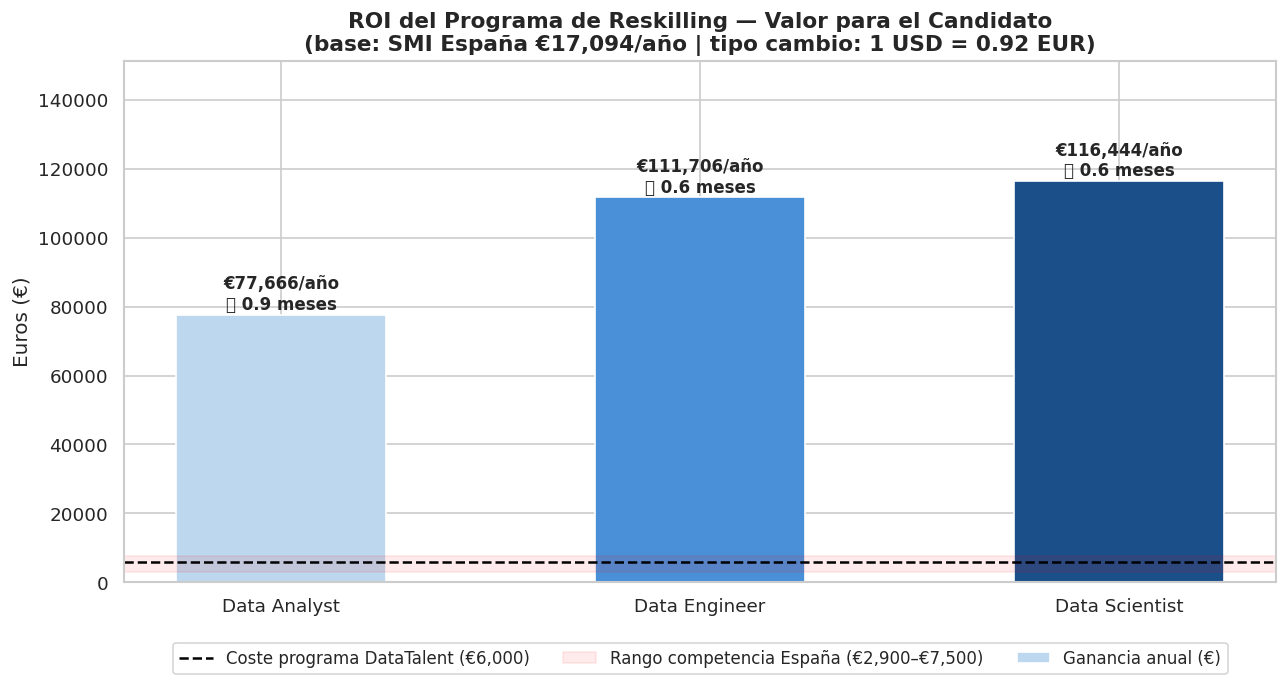

In [ ]:
# ── Reskilling ROI — Commercial Argument ─────────────────────

SALARIO_ANTES  = 1221 * 14
COSTE_PROGRAMA = 6000
USD_EUR        = 0.92
PRECIO_MIN     = 2900
PRECIO_MAX     = 7500

sal_antes_eur     = SALARIO_ANTES
sal_analyst_eur   = rol_sal.loc['Data Analyst',   'Mediana'] * USD_EUR
sal_engineer_eur  = rol_sal.loc['Data Engineer',  'Mediana'] * USD_EUR
sal_scientist_eur = rol_sal.loc['Data Scientist', 'Mediana'] * USD_EUR

ganancia_analyst   = sal_analyst_eur   - sal_antes_eur
ganancia_engineer  = sal_engineer_eur  - sal_antes_eur
ganancia_scientist = sal_scientist_eur - sal_antes_eur

meses_analyst   = COSTE_PROGRAMA / (ganancia_analyst   / 12)
meses_engineer  = COSTE_PROGRAMA / (ganancia_engineer  / 12)
meses_scientist = COSTE_PROGRAMA / (ganancia_scientist / 12)

print("=== ROI del Programa de Reskilling ===")
print(f"Salario inicial (SMI):  €{sal_antes_eur:>10,.0f}/año")
print(f"Coste del programa:     €{COSTE_PROGRAMA:>10,.0f}")
print()
print(f"{'Rol':<20} {'Salario post':>13} {'Ganancia/año':>13} {'Recupera en':>12}")
print("-" * 62)
print(f"{'Data Analyst':<20} €{sal_analyst_eur:>11,.0f} €{ganancia_analyst:>11,.0f} {meses_analyst:>10.1f} meses")
print(f"{'Data Engineer':<20} €{sal_engineer_eur:>11,.0f} €{ganancia_engineer:>11,.0f} {meses_engineer:>10.1f} meses")
print(f"{'Data Scientist':<20} €{sal_scientist_eur:>11,.0f} €{ganancia_scientist:>11,.0f} {meses_scientist:>10.1f} meses")

# ── Visualization ─────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(11, 6))

roles_roi = ['Data Analyst', 'Data Engineer', 'Data Scientist']
ganancias = [ganancia_analyst, ganancia_engineer, ganancia_scientist]
meses_roi = [meses_analyst, meses_engineer, meses_scientist]
colores   = ['#BDD7EE', '#4A90D9', '#1B4F8A']

bars = ax1.bar(roles_roi, ganancias, color=colores,
               edgecolor='white', width=0.5, label='Ganancia anual (€)')

# Program cost line
ax1.axhline(COSTE_PROGRAMA, color='black', linestyle='--', linewidth=1.5,
            label=f'Coste programa DataTalent (€{COSTE_PROGRAMA:,})')

# Competition band
ax1.axhspan(PRECIO_MIN, PRECIO_MAX, alpha=0.08, color='red',
            label=f'Rango competencia España (€{PRECIO_MIN:,}–€{PRECIO_MAX:,})')

# Labels barras
for bar, ganancia, meses in zip(bars, ganancias, meses_roi):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
             f'€{ganancia:,.0f}/año\n⏱ {meses:.1f} meses',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('ROI del Programa de Reskilling — Valor para el Candidato\n'
              f'(base: SMI España €{sal_antes_eur:,}/año | tipo cambio: 1 USD = {USD_EUR} EUR)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Euros (€)')
ax1.set_ylim(0, max(ganancias) * 1.3)
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
save_and_show('viz11_roi_reskilling.png')

## Interpretación

El gráfico cuantifica el argumento comercial más importante para DataTalent:
**el programa se paga solo en menos de 3-6 mes de trabajo.**

**Lectura por rol:**

- **Data Analyst (€77,666/año de ganancia):** el salto salarial más conservador
  pero el más realista para una primera colocación. El candidato recupera los
  €6,000 del programa en menos de 3-6 mes de trabajo en el nuevo rol.

- **Data Engineer (€111,706/año de ganancia):** ganancia un 44% superior al
  Analyst. Rol objetivo tras consolidar experiencia como Analyst.

- **Data Scientist (€116,444/año de ganancia):** el mayor retorno económico
  pero también el más exigente en términos de acceso para juniors.

**Sobre el precio del programa:**

La línea negra (€6,000) está dentro de la banda rosa — el rango de precios
de la competencia en España (€2,900–€7,500). DataTalent está posicionado
en el rango medio-alto del mercado, lo que es sostenible si el programa
incluye bolsa de empleo y acompañamiento personalizado.

**Conclusión ejecutiva:**

> *"Un candidato que invierte €6,000 en el programa recupera esa inversión
>en pocos meses de trabajo en su nuevo rol."*

> ⚠️ **Nota:** ganancias calculadas sobre salarios USA ajustados a EUR.
> En el mercado español los valores son inferiores — usar como referencia
> de tendencia, no como cifra exacta.

## Interpretación

La barra roja representa el mercado **oculto** — ofertas reales que
no podemos analizar. La barra azul es todo lo que hemos analizado
en este EDA.

**Implicación directa:** cada cifra salarial de este análisis proviene
exclusivamente de empresas que eligieron publicar su salario —
generalmente las más grandes y las que mejor pagan. El mercado real
es más amplio y probablemente paga menos.

**Para la presentación ejecutiva:** este gráfico es el argumento más
honesto que puedes mostrar al cliente — demuestra que conoces las
limitaciones de tus propios datos, lo que genera confianza.

---
## Resumen de todas las visualizaciones

| # | Tipo | Variable(s) | Hallazgo clave |
|---|------|------------|----------------|
| Intro | Pie chart + Barras horizontales | `salary_annual` × `comp_country` | Solo vemos el 32% del mercado y es 87% USA — sesgo crítico antes de cualquier análisis |
| 1 | Histograma + KDE + Normal | `salary_annual` | Distribución asimétrica positiva; media > mediana |
| 2 | Boxplot | `salary_annual` × `experience_level` | Escalera salarial clara; mayor variabilidad en niveles senior |
| 3 | Barras horizontales | `job_skills_list` | Skills de datos lideran la demanda del mercado |
| 4 | Barras verticales | `job_industries_list` | Tech y Finanzas concentran la mayoría de ofertas |
| 5 | Scatter + tendencia | `views` × `applies` | Correlación positiva moderada-alta (r=0.715): más visibilidad → más candidaturas, pero no garantiza calidad |
| 6 | Heatmap | Todas variables numéricas | Visión integrada de relaciones entre variables |
| 7 | Barras | `formatted_work_type` | Full-time domina (>80%): empleo estable |
| 8 | Barras + IC 95% | `salary_annual` × `experience_level` | Escalera salarial estadísticamente significativa; salto Entry→Mid-Senior con mayor ROI ajustado al riesgo |
| 9 | Barras horizontales + IQR | `salary_annual` × `rol` | Data Scientist lidera en salario pero con mayor variabilidad; Data Analyst es la entrada más segura |
| 10 | Barras dobles | `P(Entry\|Rol)` × `salary_annual` | Data Analyst: mayor accesibilidad para juniors con salario competitivo |
| 11 | Barras + banda competencia | `salary_annual` × `COSTE_PROGRAMA` | Programa se recupera en < 1 mes; precio competitivo en el mercado español (€2,900–€7,500) |

---
## Recomendaciones para DataTalent Solutions S.L.

1. **Currículo de reskilling:** priorizar las skills del top 5 del ranking de demanda
2. **Ruta de colocación óptima:** orientar primera colocación hacia Data Analyst — mayor P(Entry Level) y salario competitivo; escalar a Data Engineer o Data Scientist tras 2–3 años
3. **Sectores objetivo:** orientar colocación hacia Tech, Software y Financial Services; explorar Healthcare y Manufacturing como nichos con menor competencia
4. **Gestión de expectativas salariales:** usar la mediana (no la media) como referencia; alertar que el 68% de las ofertas no publica salario (sesgo al alza); ajustar cifras al mercado español
5. **Estrategia de búsqueda de empleo:** formar a candidatos para destacar en ofertas de baja visibilidad (< 20 vistas) donde la competencia es menor
6. **Argumento comercial:** el programa se recupera en menos de 6 mes de trabajo en el nuevo rol; precio dentro del rango de mercado español (€2,900–€7,500)
7. **Ampliar fuente de datos:** incorporar datasets españoles (Infojobs, Tecnoempleo, SEPE) para corregir el sesgo geográfico — España solo tiene 8 ofertas en el dataset (0.0%)
8. **Equidad de género:** cruzar con encuestas con autodeclaración de género para garantizar programas sin sesgos discriminatorios